# Decoy matching explorer

Visualises **why** the end-to-end altered-averagine decoys do (or don't) separate from real peptides.

Two views:
1. **Population** — the refined `Decon Score` distributions, target vs each decoy, with AUC. Shows the
   partial (non-)separation numerically.
2. **Per-feature matching** — for 24 features spanning the whole score range, the observed apex spectrum
   (gray sticks) overlaid with each model's placed template (target-averagine green, decoys coloured).
   This is where the laundering is visible: a decoy whose template can slide onto the real peaks scores
   high (launders); one that can't (e.g. rotated on a clean envelope) stays low.

**Data** (written by `examples/decoy_viz_export.rs`): `decoy_meta.tsv`, `decoy_series.tsv`,
`decoy_scores.tsv` in this folder. Regenerate with:
`decoy_viz_export <raw> analysis/decoy_fdr target=tgt.refined.tsv rotated=dec.refined.tsv cbp=cbp.refined.tsv off09=off09.refined.tsv`

In [1]:
import csv, os, math
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.getcwd()
for cand in (DATA_DIR, os.path.join(DATA_DIR, "analysis", "decoy_fdr"),
             os.path.join(DATA_DIR, "decoy_fdr"), "."):
    if os.path.exists(os.path.join(cand, "decoy_meta.tsv")):
        DATA_DIR = cand; break
print("data dir:", DATA_DIR)

MODELS = ["averagine", "rotated", "cbp", "off09"]
COLORS = {"averagine": "#2ca02c", "rotated": "#1f77b4", "cbp": "#d62728", "off09": "#9467bd"}

meta, order = {}, []
with open(os.path.join(DATA_DIR, "decoy_meta.tsv"), newline="") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        order.append(row["case"]); meta[row["case"]] = row

series = defaultdict(lambda: defaultdict(list))
with open(os.path.join(DATA_DIR, "decoy_series.tsv"), newline="") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        series[row["case"]][row["series"]].append((float(row["mz"]), float(row["value"])))

scores = defaultdict(list)
with open(os.path.join(DATA_DIR, "decoy_scores.tsv"), newline="") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        scores[row["model"]].append(float(row["score"]))
print(len(order), "cases;  score samples:", {k: len(v) for k, v in scores.items()})

data dir: F:\flashlfq-rust\.claude\worktrees\decoy-comb-fdr\analysis\decoy_fdr
24 cases;  score samples: {'target': 6000, 'rotated': 6000, 'cbp': 6000, 'off09': 6000, 'target_matched': 832, 'target_unmatched': 6000}


## 1. Population — recall of real peptides at the 1%-decoy threshold

The operational metric: set the Decon Score cutoff at the **99th percentile of the decoy scores** (so
only ~1% of decoys pass — a ~1% empirical FDR), then measure **recall** = the fraction of
**FlashLFQ-matched** target features (real peptides) that clear that cutoff. `target_matched` are the
target detections that hit a reference `AllQuantifiedPeaks.tsv` peak (charge + RT ±0.4 min + mass within
+10±15 ppm, the uncalibrated-raw offset). AUC (matched vs decoy) is shown alongside for context.

FlashLFQ-matched (real) target features: n=832

decoy      P99 score  recall@1%FDR  AUC(vs matched)
cbp            0.857         76.6%            0.930
off09          0.920         68.4%            0.917


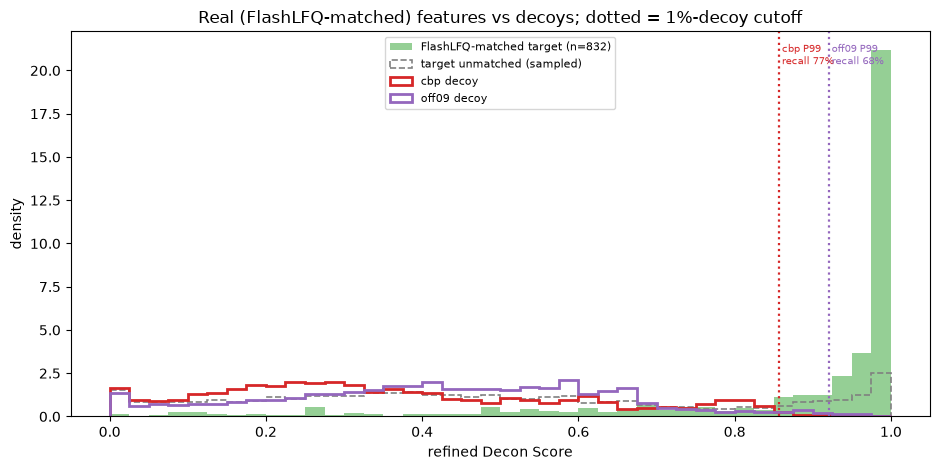

In [284]:
def auc(pos, neg):
    allv = sorted([(x, 1) for x in pos] + [(x, 0) for x in neg])
    ranks = [0.0] * len(allv); i = 0
    while i < len(allv):
        j = i
        while j < len(allv) and allv[j][0] == allv[i][0]: j += 1
        a = (i + 1 + j) / 2.0
        for k in range(i, j): ranks[k] = a
        i = j
    rs = sum(ranks[k] for k in range(len(allv)) if allv[k][1] == 1)
    n1, n0 = len(pos), len(neg)
    return (rs - n1 * (n1 + 1) / 2.0) / (n1 * n0)

def pct(v, p):
    v = np.sort(np.asarray(v, float));  return float(v[min(len(v) - 1, int(p / 100.0 * len(v)))])

matched = np.array(scores.get("target_matched", []), float)
decoys = [m for m in ["cbp", "off09"] if scores.get(m)]

print(f"FlashLFQ-matched (real) target features: n={len(matched)}\n")
print(f"{'decoy':9} {'P99 score':>10} {'recall@1%FDR':>13} {'AUC(vs matched)':>16}")
thr = {}
for m in decoys:
    t = pct(scores[m], 99); thr[m] = t
    rec = float(np.mean(matched >= t)) if len(matched) else float('nan')
    print(f"{m:9} {t:10.3f} {rec*100:12.1f}% {auc(matched, scores[m]):16.3f}")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bins = np.linspace(0, 1, 41)
ax.hist(matched, bins=bins, density=True, alpha=.5, color=COLORS["averagine"],
        label=f"FlashLFQ-matched target (n={len(matched)})")
if scores.get("target_unmatched"):
    ax.hist(scores["target_unmatched"], bins=bins, density=True, histtype="step", lw=1.2,
            color="0.5", ls="--", label="target unmatched (sampled)")
for m in decoys:
    ax.hist(scores[m], bins=bins, density=True, histtype="step", lw=2.0, color=COLORS[m],
            label=f"{m} decoy")
for m in decoys:
    rec = float(np.mean(matched >= thr[m])) if len(matched) else 0.0
    ax.axvline(thr[m], color=COLORS[m], ls=":", lw=1.6)
    ax.text(thr[m], ax.get_ylim()[1] * 0.97, f" {m} P99\n recall {rec*100:.0f}%", color=COLORS[m],
            fontsize=7, ha="left", va="top")
ax.set_xlabel("refined Decon Score"); ax.set_ylabel("density")
ax.set_title("Real (FlashLFQ-matched) features vs decoys; dotted = 1%-decoy cutoff")
ax.legend(fontsize=8, loc="upper center"); fig.tight_layout()

FlashLFQ-matched (real) target features: n=832

decoy      P99 score  recall@1%FDR  AUC(vs matched)
cbp            0.857         76.6%            0.930
off09          0.920         68.4%            0.917


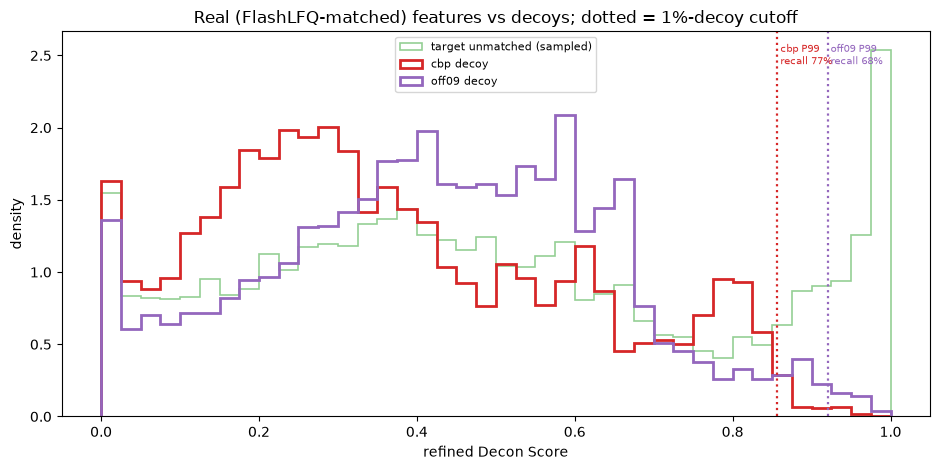

In [ ]:
matched = np.array(scores.get("target_matched", []), float)
decoys = [m for m in ["cbp", "off09"] if scores.get(m)]

print(f"FlashLFQ-matched (real) target features: n={len(matched)}\n")
print(f"{'decoy':9} {'P99 score':>10} {'recall@1%FDR':>13} {'AUC(vs matched)':>16}")
thr = {}
for m in decoys:
    t = pct(scores[m], 99); thr[m] = t
    rec = float(np.mean(matched >= t)) if len(matched) else float('nan')
    print(f"{m:9} {t:10.3f} {rec*100:12.1f}% {auc(matched, scores[m]):16.3f}")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bins = np.linspace(0, 1, 41)
""" ax.hist(matched, bins=bins, density=True, alpha=.5, color=COLORS["averagine"],
        label=f"FlashLFQ-matched target (n={len(matched)})") """
if scores.get("target_unmatched"):
    ax.hist(scores["target_unmatched"], bins=bins, density=True,
            color="#b7e4c7", alpha=0.8, label="target unmatched (sampled)")
for m in decoys:
    ax.hist(scores[m], bins=bins, density=True, histtype="step", lw=2.0, color=COLORS[m],
            label=f"{m} decoy")
for m in decoys:
    rec = float(np.mean(matched >= thr[m])) if len(matched) else 0.0
    ax.axvline(thr[m], color=COLORS[m], ls=":", lw=1.6)
    ax.text(thr[m], ax.get_ylim()[1] * 0.97, f" {m} P99\n recall {rec*100:.0f}%", color=COLORS[m],
            fontsize=7, ha="left", va="top")
ax.set_xlabel("refined Decon Score"); ax.set_ylabel("density")
ax.set_title("Real (FlashLFQ-matched) features vs decoys; dotted = 1%-decoy cutoff")
ax.legend(fontsize=8, loc="upper center"); fig.tight_layout()

## 2. Per-feature matching

`plot_case(case, models=(...))` — gray sticks = observed apex spectrum (normalised); coloured lines =
each model's template placed at the detector's seeded mono, with its envelope-fit cosine in the legend.

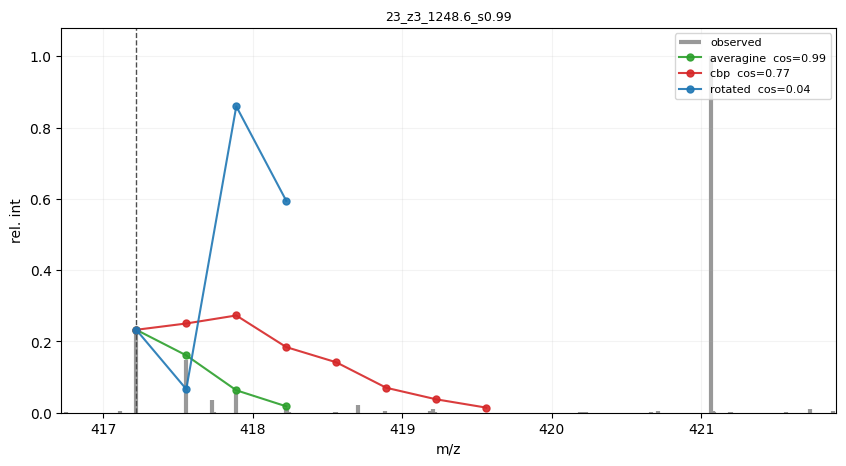

In [3]:
def grid_scale(teeth, obs, spacing):
    """Scale that overlays a template on the tallest observed peak sitting ON a theoretical tooth
    (matched within tolerance) - NOT the tallest peak in the window, which may be an off-grid
    interferent. So template[tooth of tallest matched peak] == that peak's height. 1.0 if nothing
    matches. (The envelope-fit cosine in the legend is scale-invariant and unaffected.)"""
    tol = min(0.02, 0.3 * spacing)
    best_obs, best_w = 0.0, None
    for tmz, w in teeth:
        if not obs:
            break
        near = min(obs, key=lambda p: abs(p[0] - tmz))
        if abs(near[0] - tmz) <= tol and near[1] > best_obs:
            best_obs, best_w = near[1], w
    return best_obs / best_w if best_w else 1.0

def plot_case(case, models=("averagine", "cbp"), ax=None):
    m = meta[case]; z = int(m["z"]); seed = float(m["seed_mono_mz"]); sp = float(m["spacing"])
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    obs = series[case]["observed_apex"]
    xmin = seed - 1.5 * sp
    xmax = min(seed + 14 * sp, max((mz for mz, _ in obs), default=seed + 12 * sp) + sp)
    for mz, i in obs:
        ax.vlines(mz, 0, i, color="0.6", lw=3, zorder=1)
    ax.vlines([], [], [], color="0.6", lw=3, label="observed")
    ymax = 1.0
    for name in models:
        pts = series[case].get(f"templ_{name}", [])
        cos = float(m[f"cos_{name}"])
        scale = grid_scale(pts, obs, sp)  # anchor to tallest ON-GRID observed peak, not window max
        ys = [p[1] * scale for p in pts]
        ymax = max(ymax, max(ys, default=0.0))
        ax.plot([p[0] for p in pts], ys, "-o", ms=5, lw=1.5,
                color=COLORS[name], alpha=.9, label=f"{name}  cos={cos:.2f}", zorder=3)
    ax.axvline(seed, color="0.3", ls="--", lw=1)
    ax.set_xlim(xmin, xmax); ax.set_ylim(0, ymax * 1.08)
    ax.set_title(case, fontsize=9); ax.set_xlabel("m/z"); ax.set_ylabel("rel. int")
    ax.legend(fontsize=8, loc="upper right"); ax.grid(alpha=.15)
    return ax

plot_case(order[-1], models=("averagine", "cbp", "rotated"));  # a high-scoring (clean) feature

### Interactive — pick a case and the models to overlay

In [4]:
try:
    from ipywidgets import interact, Dropdown, SelectMultiple
    def _ex(case, models):
        fig, ax = plt.subplots(figsize=(11, 5))
        plot_case(case, models=list(models) or ("averagine", "cbp"), ax=ax); plt.show()
    interact(_ex, case=Dropdown(options=order, value=order[-1], description="case"),
             models=SelectMultiple(options=MODELS, value=("averagine", "cbp"), description="models"))
except Exception as e:
    print("ipywidgets not available (%s) - use plot_case(order[i], models=(...))" % e)

ipywidgets not available (No module named 'ipywidgets') - use plot_case(order[i], models=(...))


### Overview grid — worst (top-left) to best (bottom-right) target score

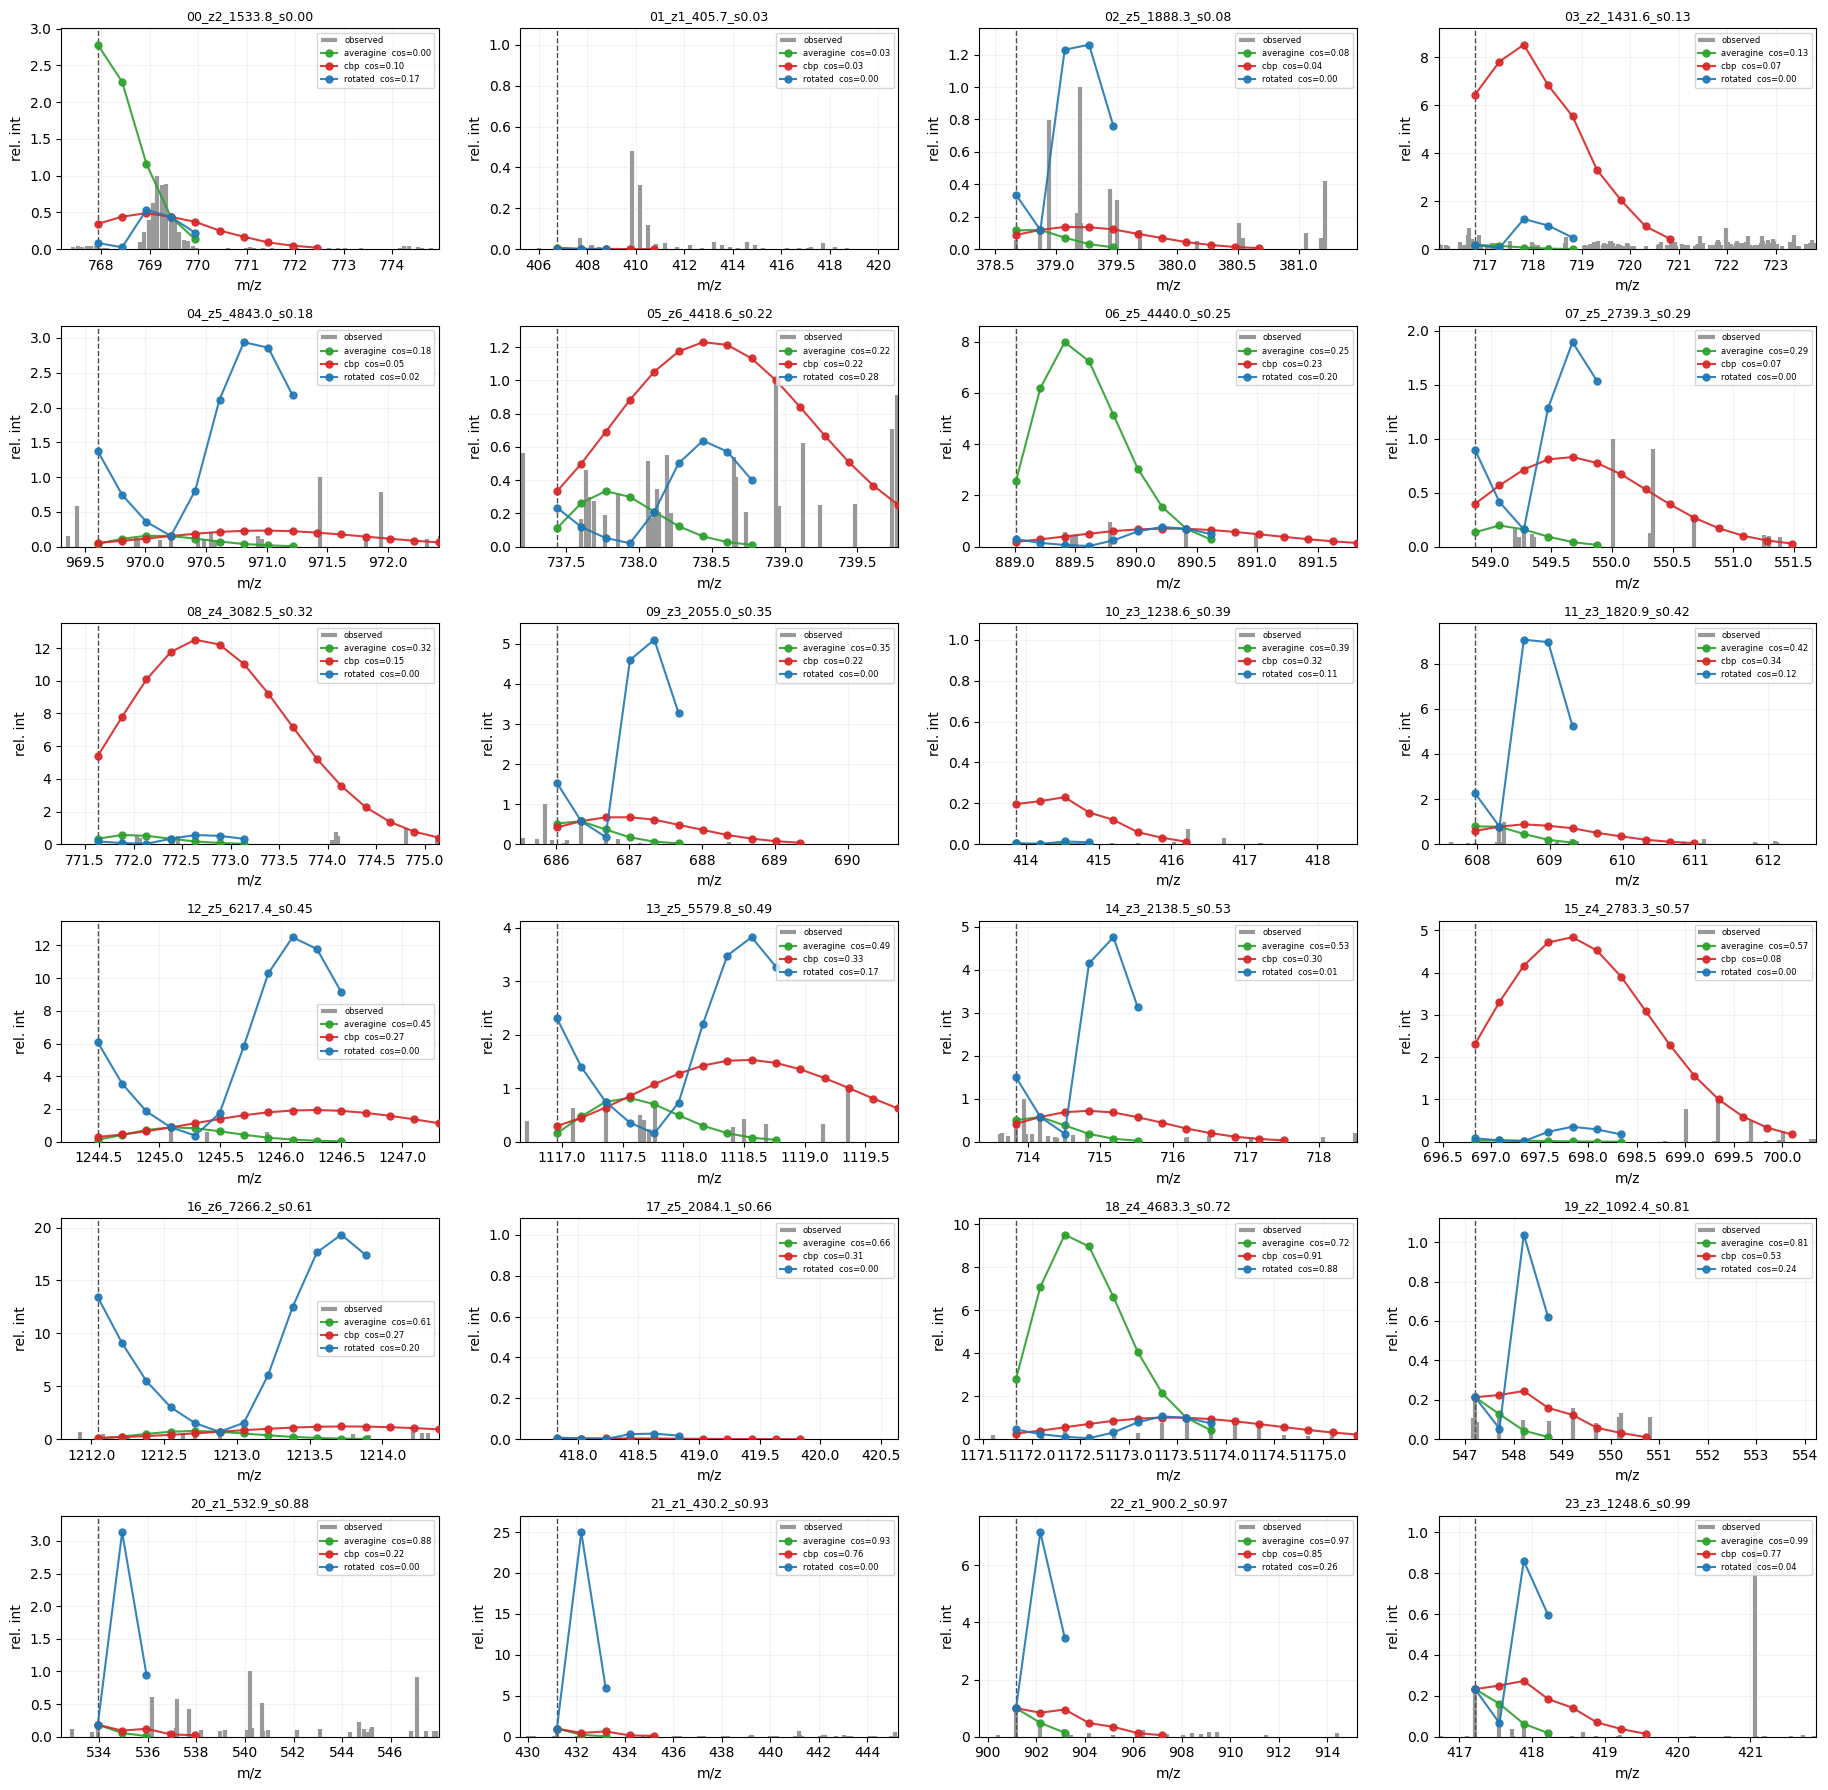

In [5]:
n = len(order); ncols = 4; nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.0 * nrows), squeeze=False)
for ax, case in zip(axes.flat, order):
    plot_case(case, models=("averagine", "cbp", "rotated"), ax=ax)
    ax.legend(fontsize=6)
for ax in list(axes.flat)[n:]:
    ax.axis("off")
fig.tight_layout()

## 3. Per-feature: decoy cosine vs target cosine

Each point is one feature. Points **below the diagonal** are ones where the decoy fits worse than the
target averagine (the decoy separating). Clustering near the diagonal = laundering (decoy fits as well
as the target).

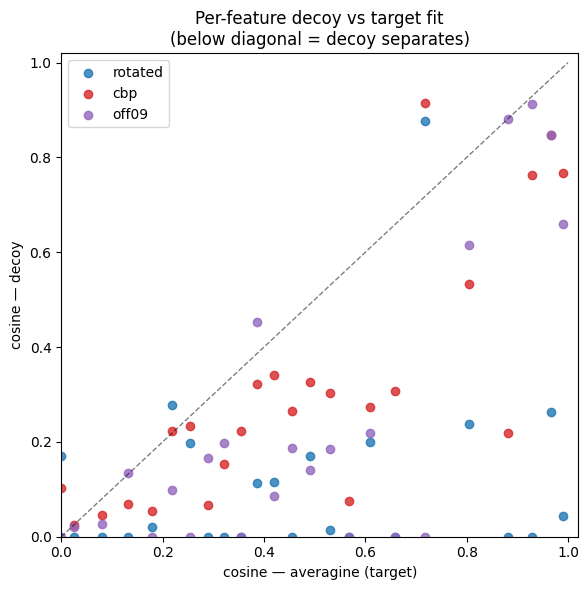

In [6]:
av = np.array([float(meta[c]["cos_averagine"]) for c in order])
fig, ax = plt.subplots(figsize=(6, 6))
for m in ["rotated", "cbp", "off09"]:
    d = np.array([float(meta[c]["cos_" + m]) for c in order])
    ax.scatter(av, d, label=m, color=COLORS[m], alpha=.8)
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=.5)
ax.set_xlabel("cosine — averagine (target)"); ax.set_ylabel("cosine — decoy")
ax.set_title("Per-feature decoy vs target fit\n(below diagonal = decoy separates)")
ax.legend(); ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); fig.tight_layout()

## 4. Build your own weird averagine

Roll your own exotic-averagine decoy and look at its isotope envelope. `plot_weird(mass, "Cl7 B7 P4")`
overlays the normal averagine (green) and the weird one (red) at a target monoisotopic mass. This is a
self-contained Python convolution of NIST isotope abundances — a *shape preview*; the exact model used
end-to-end is the Rust `ExoticAveragine` (run `weird_averagine_probe` for the authoritative binning).
Boron's ¹⁰B is what puts weight *below* k=0.

Elements available in `ISO`: C H N O S P Cl B Br Si Fe K Se Na — plus **Ge** (broad multi-modal),
**As** (monoisotopic, mass only), **Sn** (tin, 10 isotopes — the weirdest comb), **Mo** (flat-topped).
Add any others by extending `ISO` with a vector of relative abundances from the element's lightest
isotope (`0.0` for absent mass numbers). Try e.g. `plot_weird(1800, "Sn3 Ge3 As2")`.

In [37]:
e = "Cl"
n = 1
env = np.array([1.0]); principal = 0
base = np.array(ISO[e]); base = base / base.sum()
principal += int(np.argmax(base)) * n            # where the all-principal peak lands
for _ in range(n):
    env = np.convolve(env, base)[:40]
print(env)
[(k - principal, w) for k, w in enumerate(env) if w >= 0.01]

[0.7576 0.     0.2424]


[(0, np.float64(0.7576)), (2, np.float64(0.2424))]

In [75]:
 # Standard (average) atomic weights, Da — for computing an averagine unit mass.
ATOMIC_MASS = {
    "H": 1.008,   "C": 12.011,  "N": 14.007,  "O": 15.999,  "S": 32.06,
    "P": 30.9738, "Cl": 35.45,  "B": 10.81,   "Br": 79.904, "Si": 28.085,
    "Fe": 55.845, "K": 39.098,  "Se": 78.971, "Na": 22.990,
    "Ge": 72.630, "As": 74.922, "Sn": 118.710, "Mo": 95.95,
}

def unit_mass(avg):
    """Mass (Da) of one averagine 'unit' given its per-unit composition as a dict
    {element: count}. Uses average atomic weights, so the classic Senko averagine
    {'C':4.9384,'H':7.7583,'O':1.4773,'N':1.3577,'S':0.0417} -> ~111.125 Da.
    Counts may be fractional. Unknown elements raise KeyError (add them to ATOMIC_MASS)."""
    return sum(n * ATOMIC_MASS[e] for e, n in avg.items())

#Usage / sanity check:
unit_mass(AVG)                              # -> 111.1257  (matches UNIT_MASS)
unit_mass({"C": 4.9384, "H": 7.7583, "O": 1.4773, "N": 1.3577, "S": 0.0417})  # same

111.12501739999999

179.2606


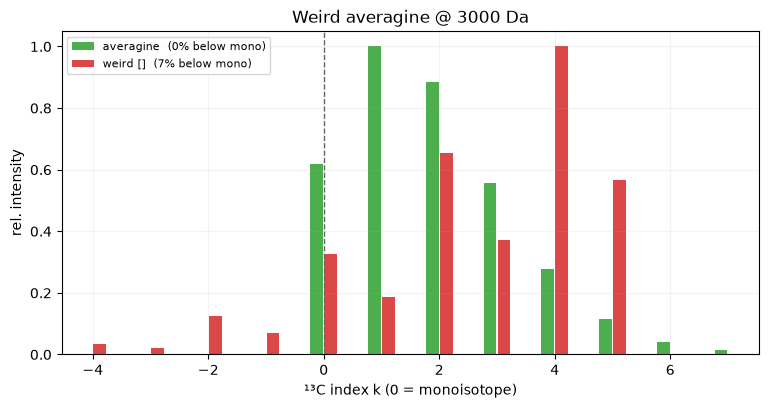

In [281]:
WRD = {"P": 2, "C": 1.0, "N": 1, "Cl": 1, "Fe": 1}
#WRD =  {"C": 4.9384, "H": 7.7583, "O": 1.4773, "N": 1.3577, "S": 0.0417, "Cl": 1.5, "Fe": 1.5}
#WRD =  {"C": 4.9384, "H": 7.7583, "O": 1.4773, "N": 1.3577, "S": 0.0417, "Cl": 0.5, "B": 0.5, "P": 0.3}
print(unit_mass(WRD))
plot_weird_2(3000, "");

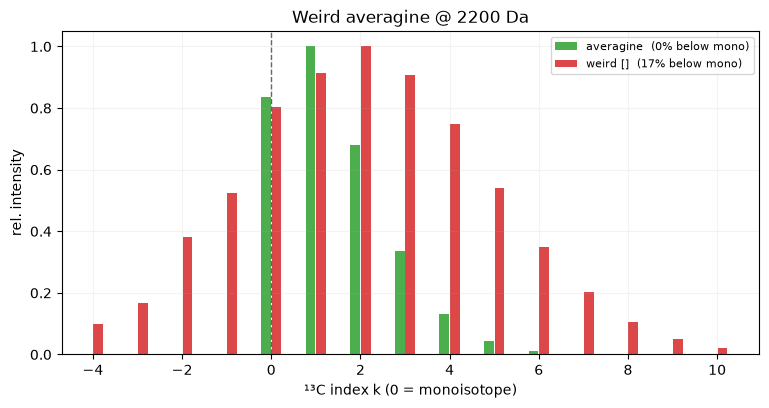

In [106]:
import re
# Relative isotope abundances at consecutive mass numbers, starting at each element's LIGHTEST isotope.
ISO = {
    "C":  [0.9893, 0.0107],
    "H":  [0.999885, 0.000115],
    "N":  [0.99636, 0.00364],
    "O":  [0.99757, 0.00038, 0.00205],
    "S":  [0.9499, 0.0075, 0.0425, 0.0, 0.0001],
    "P":  [1.0],
    "Cl": [0.7576, 0.0, 0.2424],
    "B":  [0.199, 0.801],
    "Br": [0.5069, 0.0, 0.4931],
    "Si": [0.9223, 0.0467, 0.0310],
    "Fe": [0.05845, 0.0, 0.91754, 0.02119, 0.00282],
    "K":  [0.932581, 0.000117, 0.067302],
    "Se": [0.0089, 0.0, 0.0937, 0.0763, 0.2377, 0.0, 0.4961, 0.0, 0.0873],
    "Na": [1.0],
    "Ge": [0.2057, 0.0, 0.2745, 0.0776, 0.3650, 0.0, 0.0773],          # 70,72,73,74,76 - broad, multi-modal
    "As": [1.0],                                                        # 75 only - monoisotopic (mass only)
    "Sn": [0.0097, 0.0, 0.0066, 0.0034, 0.1454, 0.0768, 0.2422,        # tin: 10 isotopes, the weirdest comb
           0.0859, 0.3258, 0.0, 0.0463, 0.0, 0.0579],
    "Mo": [0.1465, 0.0, 0.0919, 0.1587, 0.1667, 0.0958, 0.2429, 0.0, 0.0974],  # 7 isotopes, flat top
}
AVG = {"C": 4.9384, "H": 7.7583, "O": 1.4773, "N": 1.3577, "S": 0.0417}
UNIT_MASS = 111.1254  # averagine residue mass per multiplier

weird_string = "C-3 H-3 O-1 N-1 Ge1 Cl3 B2 Fe1"
#WRD = {"C": 4.9384, "H": 7.7583, "O": 1.4773, "N": 1.3577, "S": 0.0417} 
#WRD = {"Cl" : 2, "C": 3, "N": 1, "O": 1, "Ge": 0.4}#, "B" : 2, "Ge" : 1, "Fe" : 1}
#WRD = {"C": 3, "Si": 1, "Cl": 2}

def parse_formula(s):
    return {sym: int(n) for sym, n in re.findall(r"([A-Z][a-z]?)(\d+)", s)} if s else {}

def weird_comb(mass, extra="", min_rel=0.01, maxlen=40):
    """Binned isotope comb (k, weight) vs the principal-isotope monoisotope; k<0 = below the mono."""
    mult = max(mass / UNIT_MASS, 0.5)
    counts = {e: int(round(AVG[e] * mult)) for e in AVG}
    for e, n in parse_formula(extra).items():
        counts[e] = counts.get(e, 0) + n
    env = np.array([1.0]); principal = 0
    for e, n in counts.items():
        if n <= 0 or e not in ISO:
            if n > 0: print("!! no isotope data for", e);
            continue
        base = np.array(ISO[e]); base = base / base.sum()
        principal += int(np.argmax(base)) * n            # where the all-principal peak lands
        for _ in range(n):
            env = np.convolve(env, base)[:maxlen]
    env = env / env.max()
    ks = [(k - principal, w) for k, w in enumerate(env) if w >= min_rel]
    return ks

def WRD_comb(mass, extra=weird_string, min_rel=0.01, maxlen=40):
    mult = max(mass / unit_mass(WRD), 0.5)
    counts = {e: int(round(WRD[e] * mult)) for e in WRD}
    for e, n in parse_formula(extra).items():
        counts[e] = counts.get(e, 0) + n
    env = np.array([1.0]); principal = 0
    for e, n in counts.items():
        if n <= 0 or e not in ISO:
            if n > 0: print("!! no isotope data for", e);
            continue
        base = np.array(ISO[e]); base = base / base.sum()
        principal += int(np.argmax(base)) * n            # where the all-principal peak lands
        for _ in range(n):
            env = np.convolve(env, base)[:maxlen]
    env = env / env.max()
    ks = [(k - principal, w) for k, w in enumerate(env) if w >= min_rel]
    return ks

def plot_weird(mass, extra="Cl7 B7 P4", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.2))
    for lbl, ex, c, off in [("averagine", "", COLORS["averagine"], -0.12), (f"weird [{extra}]", extra, COLORS["cbp"], 0.12)]:
        ks = weird_comb(mass, ex)
        below = sum(w for k, w in ks if k < 0) / max(sum(w for _, w in ks), 1e-9)
        ax.bar([k + off for k, _ in ks], [w for _, w in ks], width=0.22, color=c, alpha=.85,
               label=f"{lbl}  ({below*100:.0f}% below mono)")
    ax.axvline(0, color="0.4", ls="--", lw=1); ax.set_xlabel("¹³C index k (0 = monoisotope)")
    ax.set_ylabel("rel. intensity"); ax.set_title(f"Weird averagine @ {mass:.0f} Da")
    ax.legend(fontsize=8); ax.grid(alpha=.15); return ax

def plot_weird_2(mass, extra="Cl7 B7 P4", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.2))
    for n, lbl, ex, c, off in [(1, "averagine", "", COLORS["averagine"], -0.12), (2, f"weird [{extra}]", extra, COLORS["cbp"], 0.12)]:
        if n == 1:
            ks = weird_comb(mass, ex)
        else:
            ks = WRD_comb(mass, ex)
        below = sum(w for k, w in ks if k < 0) / max(sum(w for _, w in ks), 1e-9)
        ax.bar([k + off for k, _ in ks], [w for _, w in ks], width=0.22, color=c, alpha=.85,
               label=f"{lbl}  ({below*100:.0f}% below mono)")
    ax.axvline(0, color="0.4", ls="--", lw=1); ax.set_xlabel("¹³C index k (0 = monoisotope)")
    ax.set_ylabel("rel. intensity"); ax.set_title(f"Weird averagine @ {mass:.0f} Da")
    ax.legend(fontsize=8); ax.grid(alpha=.15); return ax

#plot_weird(2500, "C-4 H-7 O-1 N-1 Cl5 Fe1");   # <- edit mass / formula and re-run
plot_weird_2(2200, "");   # <- edit mass / formula and re-run

### Interactive — type a target mass and a formula to add

In [8]:
try:
    from ipywidgets import interact, FloatSlider, Text
    interact(lambda mass, formula: (plot_weird(mass, formula), plt.show()),
             mass=FloatSlider(value=1500, min=400, max=4000, step=50, description="mass"),
             formula=Text(value="Cl7 B7 P4", description="add atoms"))
except Exception as e:
    print("ipywidgets not available (%s) - call plot_weird(mass, \"Cl7 B7 P4\") directly." % e)

ipywidgets not available (No module named 'ipywidgets') - call plot_weird(mass, "Cl7 B7 P4") directly.
